In [1]:
import pandas as pd

df = pd.read_csv("Main_Customer_Segmentation.csv", encoding='latin1')

C:\Users\rahul\AppData\Local\Temp\ipykernel_16764\3440397537.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Main_Customer_Segmentation.csv", encoding='latin1')


In [2]:
print(df.shape)

(541909, 8)


In [3]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  40190.3513888889       2.55     17850.0  United Kingdom  
1  40190.3513888889       3.39     17850.0  United Kingdom  
2  40190.3513888889       2.75     17850.0  United Kingdom  
3  40190.3513888889       3.39     17850.0  United Kingdom  
4  40190.3513888889       3.39     17850.0  United Kingdom  


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


## Step 3: Data Cleaning (Pandas & NumPy)

In [5]:
import numpy as np

# Remove missing values
df = df.dropna()

In [6]:
# Remove negative quantity
df = df[df['Quantity'] > 0]


In [7]:
# Remove negative price
df = df[df['UnitPrice'] > 0]


In [9]:
# Convert date

if pd.api.types.is_numeric_dtype(df['InvoiceDate']):
    df['InvoiceDate'] = pd.to_datetime(
        df['InvoiceDate'], origin='1899-12-30', unit='D'
    )
else:
    df['InvoiceDate'] = pd.to_datetime(
        df['InvoiceDate'], errors='coerce', dayfirst=True
    )

C:\Users\rahul\AppData\Local\Temp\ipykernel_16764\3908318465.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(


In [10]:
# Create total price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate    157472
UnitPrice           0
CustomerID          0
Country             0
TotalPrice          0
dtype: int64


In [11]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='object')

##  Step 4: Power BI Dashboard

In [12]:
df.to_csv("cleaned_customer_data.csv", index=False)

##  Step 5: Exploratory Data Analysis (EDA)

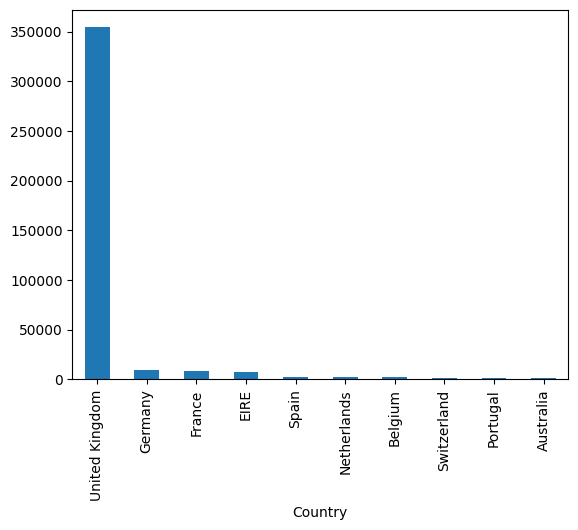

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top Countries
df['Country'].value_counts().head(10).plot(kind='bar')


plt.show()

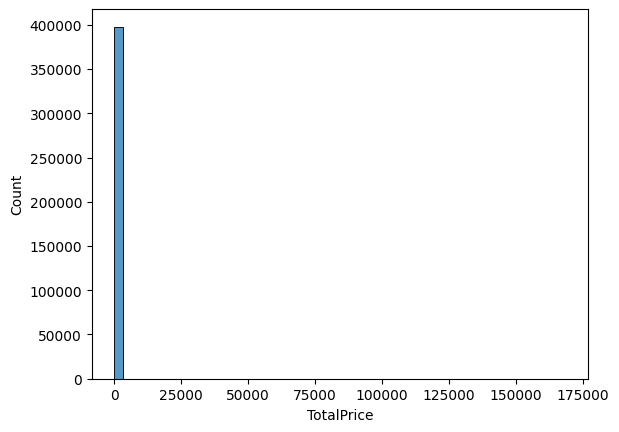

In [14]:
# Sales distribution
sns.histplot(df['TotalPrice'], bins=50)
plt.show()

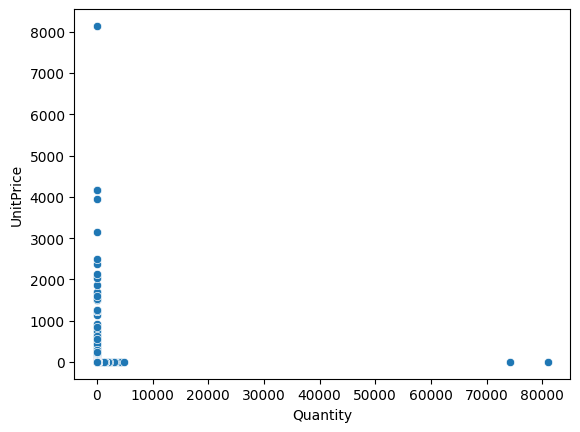

In [15]:
# Quantity vs Price
sns.scatterplot(x='Quantity', y='UnitPrice', data=df)

plt.show()

## Step 6: Feature Encoding

In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
le = LabelEncoder()

df['Country'] = le.fit_transform(df['Country'])
df['StockCode'] = le.fit_transform(df['StockCode'])

features = ['Quantity','UnitPrice','Country']

X = df[features]



In [18]:
# Target (example segmentation)
df['Segment'] = np.where(df['TotalPrice'] > 100,1,0)

y = df['Segment']

## Step 7: Machine Learning Models

In [19]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

## Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

## Decision Tree

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

## Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

## KNN

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

knn_pred = knn.predict(X_test)

## Step 8: Comparative Analysis

In [26]:
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred
}

for name,pred in models.items():
    print(name)
    print("Accuracy:",accuracy_score(y_test,pred))
    print(classification_report(y_test,pred))
    print("-------------")

Logistic Regression
Accuracy: 0.9792779320657979
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     77309
           1       0.71      0.46      0.56      2268

    accuracy                           0.98     79577
   macro avg       0.85      0.73      0.78     79577
weighted avg       0.98      0.98      0.98     79577

-------------
Decision Tree
Accuracy: 0.9999371677746083
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     77309
           1       1.00      1.00      1.00      2268

    accuracy                           1.00     79577
   macro avg       1.00      1.00      1.00     79577
weighted avg       1.00      1.00      1.00     79577

-------------
Random Forest
Accuracy: 0.9998869019942949
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     77309
           1       1.00      1.00      1.00      2268

    accuracy       

## Step 9: Save Model (.pkl file)

In [27]:
import pickle

with open("customer_segmentation_model.pkl","wb") as f:
    pickle.dump(rf,f)
    

In [28]:
model = pickle.load(open("customer_segmentation_model.pkl","rb"))

In [34]:
print(data)

RandomForestClassifier()
